In [ ]:
!pip install pysentimiento

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 24.5 MB/s eta 0:00:00


In [ ]:
from pysentimiento import create_analyzer
import pandas as pd
import re

analyzer = create_analyzer(task="sentiment", lang="es")

df_clean = pd.read_csv("datos_clean.csv")
df_clean["texto_clean"] = df_clean["texto_clean"].fillna("")

# Filtrar noticias sobre Pedro Sánchez
patron = re.compile(
    r'\bpedro\s+s[áa]nchez\b'
    r'|\bel\s+presidente\s+del\s+gobierno\b'
    r'|\bel\s+presidente\s+s[áa]nchez\b'
    r'|\bel\s+l[íi]der\s+del\s+psoe\b',
    re.IGNORECASE
)
df_s_clean = df_clean[df_clean["texto_clean"].str.contains(patron) | df_clean["titulo"].str.contains(patron)].copy()

# Extraer solo las frases que mencionan a Sánchez (contexto)
def contexto_sanchez(texto, ventana=10):
    frases = re.split(r"(?<=[\.\!\?])\s+", texto)
    idx = set()
    for i, f in enumerate(frases):
        if patron.search(f):
            idx.update(range(max(0, i-ventana), min(len(frases), i+ventana+1)))
    return " ".join(frases[i] for i in sorted(idx))[:1500]  # truncar para BERT

df_s_clean["contexto"] = df_s_clean["texto_clean"].apply(contexto_sanchez)

# Predecir sentimiento (POS / NEG / NEU)
df_s_clean["sentimiento"] = df_s_clean["contexto"].apply(lambda t: analyzer.predict(t).output)

# Score numérico para promediar
mapa = {"POS": 1, "NEU": 0, "NEG": -1}
df_s_clean["score"] = df_s_clean["sentimiento"].map(mapa)

# Resumen por periódico
print(df_s_clean.groupby("periodico")["score"].agg(["mean", "count"]))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

                         mean  count
periodico                           
Público             -0.660000    200
Tercera Información -0.583333     60
el español          -0.560878    501
eldiario.es         -0.590278    144
la razon            -0.725686    401


In [ ]:
# Tabla con URL y sentimiento de cada artículo
resultado = df_s_clean[['periodico', 'titulo', 'url', 'sentimiento']].copy()

# Mostrar todas las URLs sin truncar
pd.set_option('display.max_colwidth', None)

print(resultado)

# Guardar a CSV
resultado.to_csv('articulos_sentimiento.csv', index=False)

        periodico  \
39    eldiario.es   
84    eldiario.es   
120   eldiario.es   
121   eldiario.es   
123   eldiario.es   
...           ...   
9988   el español   
9995   el español   
9997   el español   
9998   el español   
9999   el español   

                                                                        titulo  \
39                                Hombre blanco hablar con lengua de serpiente   
84                             Antonio Maíllo parando drones de Pablo Iglesias   
120       ANDALUCES EMIGRAOS De adelantos electorales y votar en el extranjero   
121                                                               El cro-mañón   
123                                             La hora de María Jesús Montero   
...                                                                        ...   
9988                                              socialistas en ninguna parte   
9995    a vox en grito: el radicalismo de sánchez dispara a la extrema derecha   
9997  dos

In [ ]:
positivos = df_s_clean[df_s_clean['sentimiento'] == 'POS'][['periodico', 'titulo', 'url']]
print(positivos)

                periodico  \
2095             la razon   
3049             la razon   
4085              Público   
5444              Público   
5601              Público   
5864              Público   
6086  Tercera Información   
6417  Tercera Información   
8235           el español   
8687           el español   
8876           el español   
8921           el español   
8938           el español   
8998           el español   
9017           el español   
9156           el español   
9237           el español   
9266           el español   
9764           el español   

                                                                                    titulo  \
2095                             El absentismo laboral se disparó un 42% con Pedro Sánchez   
3049                                                                      ¿No a la guerra?   
4085                                               Por fin una gran cumbre de la izquierda   
5444                                   El f

In [ ]:
print(df_s_clean.loc[8938, 'texto_clean'])

apuesto generaldick browning jefe fuerzas aerotransportadas británicas hombre singular conocido boy browning tiempos eton campeón bobsleigh casado condaphne du maurier autora derebecaolos pájaros influido quizá literatura misterio labios brotó frases marcaron etapa final segunda guerra mundial pasado antologías arte guerra refiere fracaso laoperación marketgardenque pretendía acelerar jaque mate contrahitler tomando serie puentes holanda mediante arriesgadas operaciones comandos jefe generalmontgomery señaló mapa objetivos browning preguntó cuánto tardarían paracaidistas recibir refuerzos terrestres monty dijo dos días puente lejanotomás serrano replicó podrían resistir cuatro añadió creo yendo puente demasiado lejos refería puente arnhem casi cien kilómetros allá líneas defensivas alemanas protegido importante contingente blindados historiadorcornelius ryany directorrichard attenboroughinmortalizaron expresión bridge too far libro película mismo nombre película browning suelta interlo

In [ ]:
df_s_clean.head()

periodico  \
39   eldiario.es   
84   eldiario.es   
120  eldiario.es   
121  eldiario.es   
123  eldiario.es   

                                                                   titulo  \
39                           Hombre blanco hablar con lengua de serpiente   
84                        Antonio Maíllo parando drones de Pablo Iglesias   
120  ANDALUCES EMIGRAOS De adelantos electorales y votar en el extranjero   
121                                                          El cro-mañón   
123                                        La hora de María Jesús Montero   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

sentimiento          POS  NEU  NEG
periodico                         
el español            12  196  293
Público                4   60  136
Tercera Información    2   21   37
la razon               2  106  293
eldiario.es            0   59   85


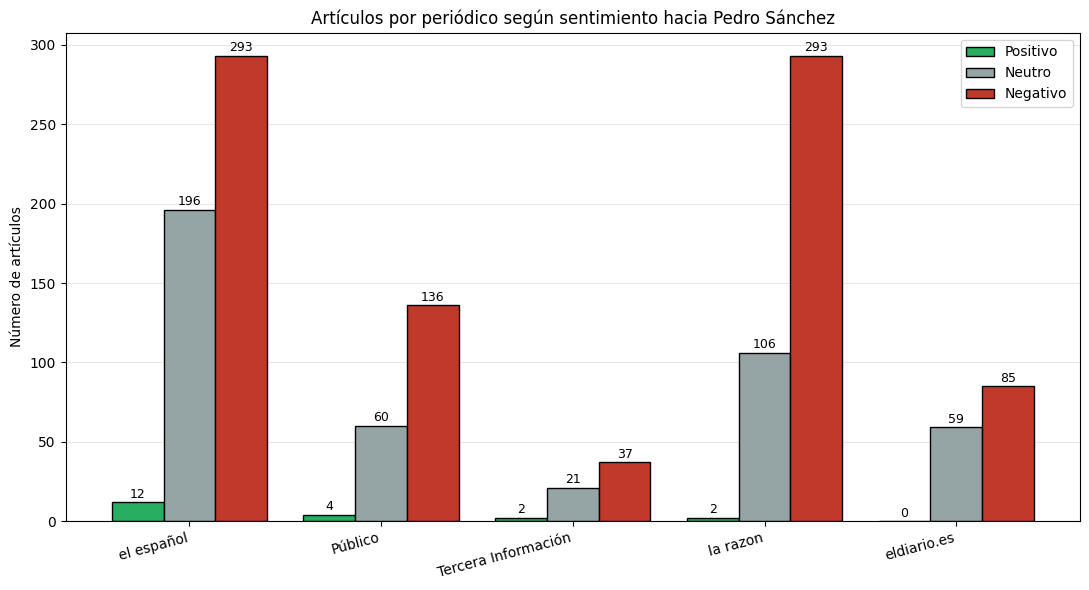

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Recuento absoluto por periódico y sentimiento
recuento = df_s_clean.groupby(['periodico', 'sentimiento']).size().unstack(fill_value=0)

# Asegurar que están las tres columnas en orden
for col in ['POS', 'NEU', 'NEG']:
    if col not in recuento.columns:
        recuento[col] = 0
recuento = recuento[['POS', 'NEU', 'NEG']]
recuento = recuento.sort_values('POS', ascending=False)

print(recuento)

# Gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(recuento))
ancho = 0.27

b1 = ax.bar(x - ancho, recuento['POS'], ancho, label='Positivo', color='#27ae60', edgecolor='black')
b2 = ax.bar(x,         recuento['NEU'], ancho, label='Neutro',   color='#95a5a6', edgecolor='black')
b3 = ax.bar(x + ancho, recuento['NEG'], ancho, label='Negativo', color='#c0392b', edgecolor='black')

# Números encima de cada barra
for barras in (b1, b2, b3):
    for b in barras:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                f'{int(b.get_height())}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(recuento.index, rotation=15, ha='right')
ax.set_ylabel('Número de artículos')
ax.set_title('Artículos por periódico según sentimiento hacia Pedro Sánchez')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### CON EL DATASET SIN LIMPIAR

In [ ]:
from pysentimiento import create_analyzer
import pandas as pd
import re

analyzer = create_analyzer(task="sentiment", lang="es")

df = pd.read_csv("datos_unidos.csv")
df["texto"] = df["texto"].fillna("")

# Filtrar noticias sobre Pedro Sánchez
patron = re.compile(
    r'\bpedro\s+s[áa]nchez\b'
    r'|\bel\s+presidente\s+del\s+gobierno\b'
    r'|\bel\s+presidente\s+s[áa]nchez\b'
    r'|\bel\s+l[íi]der\s+del\s+psoe\b',
    re.IGNORECASE
)
df_s = df[df["texto"].str.contains(patron) | df["titulo"].str.contains(patron)].copy()

# Extraer solo las frases que mencionan a Sánchez (contexto)
def contexto_sanchez(texto, ventana=5):
    frases = re.split(r"(?<=[\.\!\?])\s+", texto)
    idx = set()
    for i, f in enumerate(frases):
        if patron.search(f):
            idx.update(range(max(0, i-ventana), min(len(frases), i+ventana+1)))
    return " ".join(frases[i] for i in sorted(idx))[:1500]  # truncar para BERT

df_s["contexto"] = df_s["texto"].apply(contexto_sanchez)

# Predecir sentimiento (POS / NEG / NEU)
df_s["sentimiento"] = df_s["contexto"].apply(lambda t: analyzer.predict(t).output)

# Score numérico para promediar
mapa = {"POS": 1, "NEU": 0, "NEG": -1}
df_s["score"] = df_s["sentimiento"].map(mapa)

# Resumen por periódico
print(df_s.groupby("periodico")["score"].agg(["mean", "count"]))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

                         mean  count
periodico                           
Público             -0.813620    279
Tercera Información -0.854839     62
el español          -0.848160    652
eldiario.es         -0.830918    207
la razon            -0.872984    496


sentimiento          POS  NEU  NEG
periodico                         
el español            20   68  564
la razon              11   40  445
Público                8   38  233
eldiario.es            7   28  172
Tercera Información    2    5   55


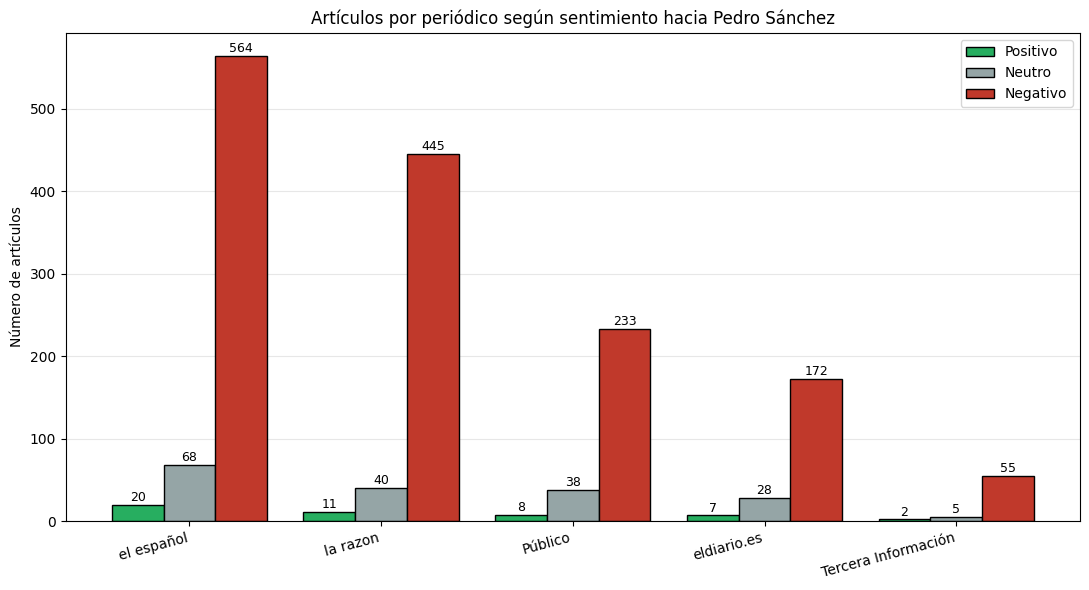

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Recuento absoluto por periódico y sentimiento
recuento = df_s.groupby(['periodico', 'sentimiento']).size().unstack(fill_value=0)

# Asegurar que están las tres columnas en orden
for col in ['POS', 'NEU', 'NEG']:
    if col not in recuento.columns:
        recuento[col] = 0
recuento = recuento[['POS', 'NEU', 'NEG']]
recuento = recuento.sort_values('POS', ascending=False)

print(recuento)

# Gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(recuento))
ancho = 0.27

b1 = ax.bar(x - ancho, recuento['POS'], ancho, label='Positivo', color='#27ae60', edgecolor='black')
b2 = ax.bar(x,         recuento['NEU'], ancho, label='Neutro',   color='#95a5a6', edgecolor='black')
b3 = ax.bar(x + ancho, recuento['NEG'], ancho, label='Negativo', color='#c0392b', edgecolor='black')

# Números encima de cada barra
for barras in (b1, b2, b3):
    for b in barras:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                f'{int(b.get_height())}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(recuento.index, rotation=15, ha='right')
ax.set_ylabel('Número de artículos')
ax.set_title('Artículos por periódico según sentimiento hacia Pedro Sánchez')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [ ]:
from pysentimiento import create_analyzer
import pandas as pd
import re

analyzer = create_analyzer(task="sentiment", lang="es")

df = pd.read_csv("datos_unidos.csv")
df["texto"] = df["texto"].fillna("")

patron = re.compile(
    r'\bpedro\s+s[áa]nchez\b'
    r'|\bel\s+presidente\s+del\s+gobierno\b'
    r'|\bel\s+presidente\s+s[áa]nchez\b'
    r'|\bel\s+l[íi]der\s+del\s+psoe\b',
    re.IGNORECASE
)

df_s = df[df["texto"].str.contains(patron) | df["titulo"].str.contains(patron)].copy()

# Extraer contexto SIN truncar
def contexto_sanchez(texto, ventana=0):
    if not isinstance(texto, str):
        return ""
    frases = re.split(r"(?<=[\.\!\?])\s+", texto)
    idx = set()
    for i, f in enumerate(frases):
        if patron.search(f):
            idx.update(range(max(0, i-ventana), min(len(frases), i+ventana+1)))
    return " ".join(frases[i] for i in sorted(idx))

df_s["contexto"] = df_s["texto"].apply(contexto_sanchez)
df_s = df_s[df_s["contexto"].str.strip() != ""].copy()

# Trocear y promediar probabilidades
def predecir_largo(texto, max_chars=1500):
    bloques = [texto[i:i+max_chars] for i in range(0, len(texto), max_chars)]
    bloques = [b for b in bloques if b.strip()]
    if not bloques:
        return "NEU"
    sumas = {"POS": 0.0, "NEU": 0.0, "NEG": 0.0}
    for b in bloques:
        pred = analyzer.predict(b)
        for k in sumas:
            sumas[k] += pred.probas[k]
    return max(sumas, key=sumas.get)

print(f"Procesando {len(df_s)} artículos...")
df_s["sentimiento"] = df_s["contexto"].apply(predecir_largo)

mapa = {"POS": 1, "NEU": 0, "NEG": -1}
df_s["score"] = df_s["sentimiento"].map(mapa)

print(df_s.groupby("periodico")["score"].agg(["mean", "count"]))

ModuleNotFoundError: No module named 'pysentimiento'

sentimiento          POS  NEU  NEG
periodico                         
el español            18   63  571
la razon               9   45  442
Público                7   38  234
eldiario.es            4   27  176
Tercera Información    2    5   55


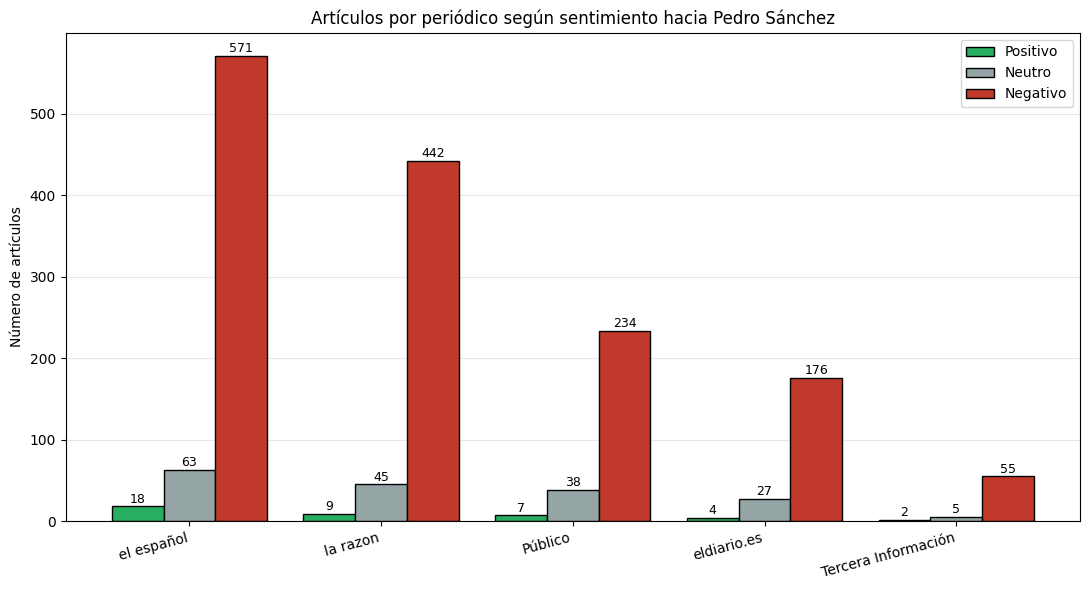

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Recuento absoluto por periódico y sentimiento
recuento = df_s.groupby(['periodico', 'sentimiento']).size().unstack(fill_value=0)

# Asegurar que están las tres columnas en orden
for col in ['POS', 'NEU', 'NEG']:
    if col not in recuento.columns:
        recuento[col] = 0
recuento = recuento[['POS', 'NEU', 'NEG']]
recuento = recuento.sort_values('POS', ascending=False)

print(recuento)

# Gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(recuento))
ancho = 0.27

b1 = ax.bar(x - ancho, recuento['POS'], ancho, label='Positivo', color='#27ae60', edgecolor='black')
b2 = ax.bar(x,         recuento['NEU'], ancho, label='Neutro',   color='#95a5a6', edgecolor='black')
b3 = ax.bar(x + ancho, recuento['NEG'], ancho, label='Negativo', color='#c0392b', edgecolor='black')

# Números encima de cada barra
for barras in (b1, b2, b3):
    for b in barras:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                f'{int(b.get_height())}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(recuento.index, rotation=15, ha='right')
ax.set_ylabel('Número de artículos')
ax.set_title('Artículos por periódico según sentimiento hacia Pedro Sánchez')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [ ]:
# Proporción de sentimiento por periódico (en %)
proporcion = (
    df_s.groupby('periodico')['sentimiento']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        * 100
)

# Asegurar que están las tres columnas
for col in ['POS', 'NEU', 'NEG']:
    if col not in proporcion.columns:
        proporcion[col] = 0
proporcion = proporcion[['POS', 'NEU', 'NEG']].round(1)

# Ordenar de más favorable (más POS, menos NEG) a menos
proporcion['favorabilidad'] = proporcion['POS'] - proporcion['NEG']
proporcion = proporcion.sort_values('favorabilidad', ascending=False)

print("Porcentaje de artículos por sentimiento (%):")
print(proporcion)

print("\nRanking de favorabilidad hacia Pedro Sánchez:")
for i, (periodico, fila) in enumerate(proporcion.iterrows(), 1):
    signo = '+' if fila['favorabilidad'] >= 0 else ''
    print(f"  {i}. {periodico:25s} {fila['POS']:5.1f}% POS | {fila['NEG']:5.1f}% NEG | balance: {signo}{fila['favorabilidad']:.1f}")

Porcentaje de artículos por sentimiento (%):
sentimiento          POS   NEU   NEG  favorabilidad
periodico                                          
Público              2.5  13.6  83.9          -81.4
eldiario.es          1.9  13.0  85.0          -83.1
el español           2.8   9.7  87.6          -84.8
Tercera Información  3.2   8.1  88.7          -85.5
la razon             1.8   9.1  89.1          -87.3

Ranking de favorabilidad hacia Pedro Sánchez:
  1. Público                     2.5% POS |  83.9% NEG | balance: -81.4
  2. eldiario.es                 1.9% POS |  85.0% NEG | balance: -83.1
  3. el español                  2.8% POS |  87.6% NEG | balance: -84.8
  4. Tercera Información         3.2% POS |  88.7% NEG | balance: -85.5
  5. la razon                    1.8% POS |  89.1% NEG | balance: -87.3


In [ ]:
# Proporción de sentimiento por periódico (en %)
proporcion = (
    df_s_clean.groupby('periodico')['sentimiento']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        * 100
)

# Asegurar que están las tres columnas
for col in ['POS', 'NEU', 'NEG']:
    if col not in proporcion.columns:
        proporcion[col] = 0
proporcion = proporcion[['POS', 'NEU', 'NEG']].round(1)

# Ordenar de más favorable (más POS, menos NEG) a menos
proporcion['favorabilidad'] = proporcion['POS'] - proporcion['NEG']
proporcion = proporcion.sort_values('favorabilidad', ascending=False)

print("Porcentaje de artículos por sentimiento (%):")
print(proporcion)

print("\nRanking de favorabilidad hacia Pedro Sánchez:")
for i, (periodico, fila) in enumerate(proporcion.iterrows(), 1):
    signo = '+' if fila['favorabilidad'] >= 0 else ''
    print(f"  {i}. {periodico:25s} {fila['POS']:5.1f}% POS | {fila['NEG']:5.1f}% NEG | balance: {signo}{fila['favorabilidad']:.1f}")

Porcentaje de artículos por sentimiento (%):
sentimiento          POS   NEU   NEG  favorabilidad
periodico                                          
el español           2.4  39.1  58.5          -56.1
Tercera Información  3.3  35.0  61.7          -58.4
eldiario.es          0.0  41.0  59.0          -59.0
Público              2.0  30.0  68.0          -66.0
la razon             0.5  26.4  73.1          -72.6

Ranking de favorabilidad hacia Pedro Sánchez:
  1. el español                  2.4% POS |  58.5% NEG | balance: -56.1
  2. Tercera Información         3.3% POS |  61.7% NEG | balance: -58.4
  3. eldiario.es                 0.0% POS |  59.0% NEG | balance: -59.0
  4. Público                     2.0% POS |  68.0% NEG | balance: -66.0
  5. la razon                    0.5% POS |  73.1% NEG | balance: -72.6
